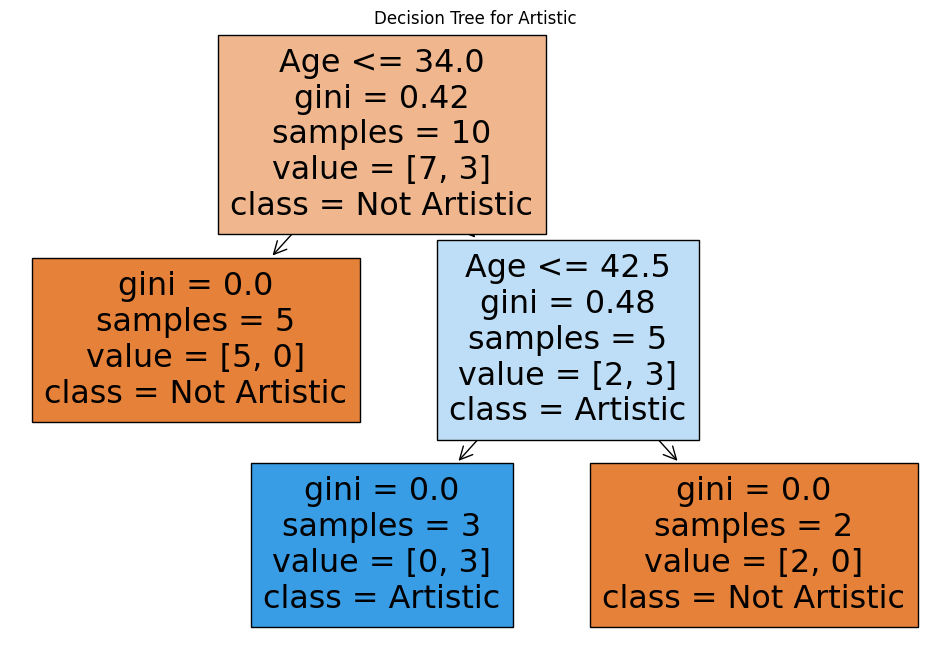

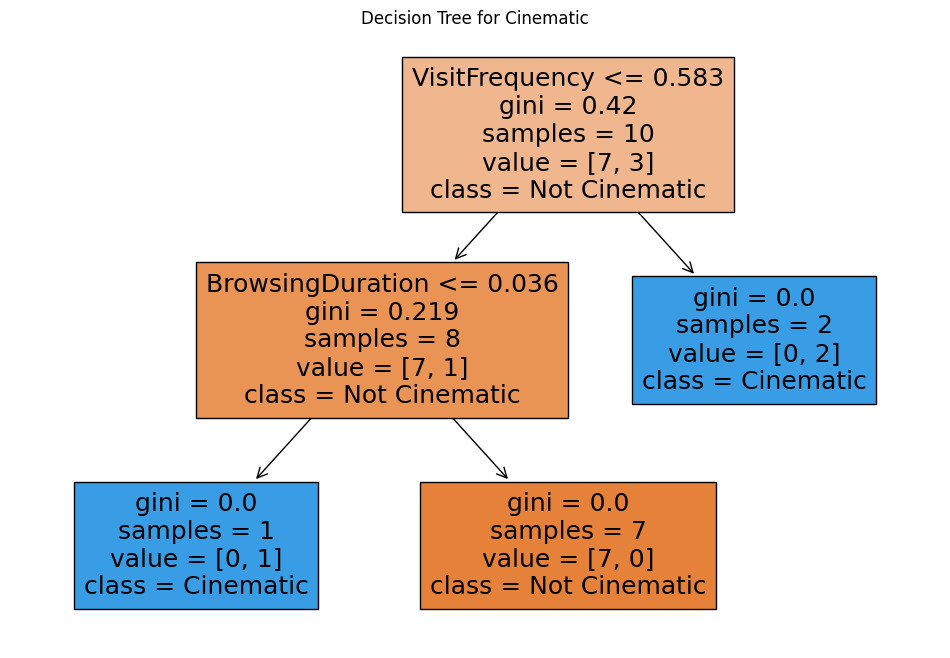

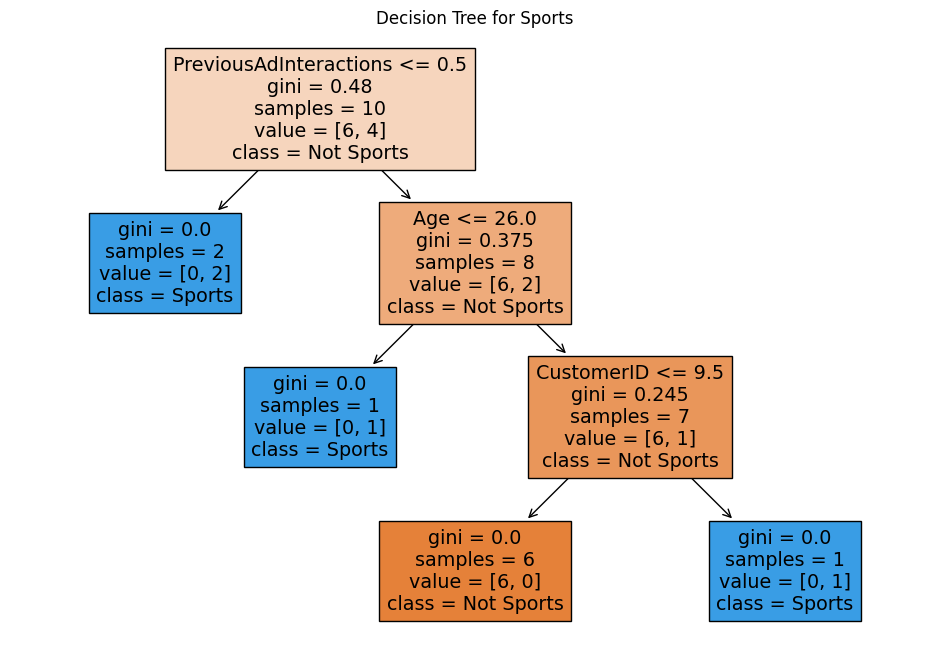

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Load the dataset
data = pd.DataFrame({
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age': [25, 32, 40, 28, 45, 35, 50, 27, 38, 33],
    'Gender_Female': [0, 1, 0, 1, 1, 0, 0, 1, 1, 0],
    'Gender_Male': [1, 0, 1, 0, 0, 1, 1, 0, 0, 1],
    'BrowsingDuration': [0.142857, 0.314286, 0.071429, 0.485714, 0.214286, 0.385714, 0.1, 0.0, 0.257143, 0.171429],
    'VisitFrequency': [0.333333, 0.666667, 0.166667, 0.5, 0.833333, 0.333333, 0.0, 0.166667, 0.5, 0.333333],
    'PreviousAdInteractions': [2, 1, 3, 0, 2, 1, 0, 1, 2, 1],
    'ShoppingHabits_Frequent': [0, 1, 0, 0, 0, 0, 1, 1, 0, 0],
    'ShoppingHabits_Occasional': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'ShoppingHabits_RegularBuyer': [1, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    'DeviceType_Desktop': [1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
    'DeviceType_Mobile': [0, 1, 1, 0, 1, 0, 1, 0, 0, 0],
    'Browser_Chrome': [1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
    'Browser_Firefox': [0, 1, 0, 0, 0, 0, 1, 1, 0, 0],
    'Browser_Safari': [0, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    'BannerAd': ['Sports', 'Cinematic', 'Artistic', 'Sports', 'Cinematic', 'Artistic', 'Sports', 'Cinematic', 'Artistic', 'Sports']
})

# One-hot encode categorical columns
data = pd.get_dummies(data, columns=['BannerAd'])

# Iterate over each banner type
for banner_type in data.columns[data.columns.str.startswith('BannerAd_')]:
    # Split the features and target variable
    X = data.drop(banner_type, axis=1)
    y = data[banner_type]
    
    # Initialize and train the decision tree classifier
    model = DecisionTreeClassifier()
    model.fit(X, y)
    
    # Visualize the decision tree
    fig = plt.figure(figsize=(12, 8))
    _ = tree.plot_tree(model, feature_names=X.columns, 
                       class_names=['Not ' + banner_type.split('_')[1], 
                                    banner_type.split('_')[1]], filled=True)
    plt.title(f'Decision Tree for {banner_type.split("_")[1]}')
    plt.show()
    
    

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Load the dataset
data = pd.DataFrame({
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age': [25, 32, 40, 28, 45, 35, 50, 27, 38, 33],
    'Gender_Female': [0, 1, 0, 1, 1, 0, 0, 1, 1, 0],
    'Gender_Male': [1, 0, 1, 0, 0, 1, 1, 0, 0, 1],
    'BrowsingDuration': [0.142857, 0.314286, 0.071429, 0.485714, 0.214286, 0.385714, 0.1, 0.0, 0.257143, 0.171429],
    'VisitFrequency': [0.333333, 0.666667, 0.166667, 0.5, 0.833333, 0.333333, 0.0, 0.166667, 0.5, 0.333333],
    'PreviousAdInteractions': [2, 1, 3, 0, 2, 1, 0, 1, 2, 1],
    'ShoppingHabits_Frequent': [0, 1, 0, 0, 0, 0, 1, 1, 0, 0],
    'ShoppingHabits_Occasional': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'ShoppingHabits_RegularBuyer': [1, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    'DeviceType_Desktop': [1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
    'DeviceType_Mobile': [0, 1, 1, 0, 1, 0, 1, 0, 0, 0],
    'Browser_Chrome': [1, 0, 0, 1, 0, 1, 0, 1, 0, 1],
    'Browser_Firefox': [0, 1, 0, 0, 0, 0, 1, 1, 0, 0],
    'Browser_Safari': [0, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    'BannerAd': ['Sports', 'Cinematic', 'Artistic', 'Sports', 'Cinematic', 'Artistic', 'Sports', 'Cinematic', 'Artistic', 'Sports']
})

# Split the dataset into features and target variable
X = data.drop('BannerAd', axis=1)
y = data['BannerAd']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
model = RandomForestClassifier()

# Measure the time taken for training
start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate the robustness of the model by performing cross-validation
robustness_scores = cross_val_score(model, X, y, cv=5)  # Adjust cv value as needed
robustness = robustness_scores.mean()

# Calculate the speed of the model by measuring the prediction time
start_time = time.time()
model.predict(X_test.iloc[0:1, :])  # Predict on a single sample for demonstration
prediction_time = time.time() - start_time

# Interpretability of the model is high for Random Forest as it provides feature importances
feature_importances = model.feature_importances_

# Scalability depends on the size of the dataset and the resources available

# Print the evaluation metrics
print("Accuracy:", accuracy)
print("Robustness:", robustness)
print("Training Time:", training_time)
print("Prediction Time:", prediction_time)
print("Feature Importances:", feature_importances)


ValueError: n_splits=5 cannot be greater than the number of members in each class.